# G1 - Employee Predictive Modeling with Machine Learning
**Artificial Intelligence Project — ESMAD / Politécnico do Porto**

This notebook covers the full pipeline for two predictive tasks:
- **Regression:** Predict `MonthlyIncome` (R2 metric)
- **Classification:** Predict `Attrition` (F1-macro metric)


## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, KFold,
    RandomizedSearchCV
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Data

In [5]:
df = pd.read_csv('../employee_data/employee_data.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1249, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,34,No,Travel_Frequently,702,Research & Development,16,4,Life Sciences,1,838,...,3,80,0,6,3,3,5,2,1,3
1,38,No,Travel_Rarely,833,Research & Development,18,3,Medical,1,1766,...,3,80,1,15,2,3,1,0,1,0
2,51,No,Travel_Rarely,833,Research & Development,1,3,Life Sciences,1,353,...,2,80,0,1,0,2,1,0,0,0
3,60,No,Travel_Rarely,1179,Sales,16,4,Marketing,1,732,...,4,80,0,10,1,3,2,2,2,2
4,23,No,Travel_Rarely,571,Research & Development,12,2,Other,1,1982,...,3,80,0,5,6,4,5,2,1,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1249 entries, 0 to 1248
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1249 non-null   int64 
 1   Attrition                 1249 non-null   object
 2   BusinessTravel            1249 non-null   object
 3   DailyRate                 1249 non-null   int64 
 4   Department                1249 non-null   object
 5   DistanceFromHome          1249 non-null   int64 
 6   Education                 1249 non-null   int64 
 7   EducationField            1249 non-null   object
 8   EmployeeCount             1249 non-null   int64 
 9   EmployeeNumber            1249 non-null   int64 
 10  EnvironmentSatisfaction   1249 non-null   int64 
 11  Gender                    1249 non-null   object
 12  HourlyRate                1249 non-null   int64 
 13  JobInvolvement            1249 non-null   int64 
 14  JobLevel                

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1249.000000,1249.000000,1249.000000,1249.000000,1249.0,1249.000000,1249.000000,1249.000000,1249.000000,1249.000000,...,1249.000000,1249.0,1249.000000,1249.000000,1249.000000,1249.000000,1249.000000,1249.000000,1249.000000,1249.000000
mean,37.031225,803.306645,9.274620,2.905524,1.0,1021.179343,2.720576,65.612490,2.735789,2.061649,...,2.731785,80.0,0.784628,11.323459,2.776621,2.758207,7.048839,4.230584,2.202562,4.177742
std,9.181389,403.046710,8.112925,1.021740,0.0,604.349113,1.092472,20.378676,0.705297,1.093488,...,1.084989,0.0,0.847822,7.834083,1.275596,0.713300,6.175584,3.607950,3.280155,3.602721
min,18.000000,103.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,486.000000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1011.000000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.000000,4.000000,83.000000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2065.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 3. Exploratory Data Analysis (EDA)

### 3.1 Missing Values

In [8]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

Missing values per column:
No missing values found.


### 3.2 Constant / Useless Columns

In [9]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(f'Constant column: {col} -> {df[col].unique()}')

# These columns carry no predictive information:
# EmployeeCount (always 1), Over18 (always Y), StandardHours (always 80)
# EmployeeNumber is just an ID
DROP_COLS = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
print(f'\nColumns to drop: {DROP_COLS}')

Constant column: EmployeeCount -> [1]
Constant column: Over18 -> ['Y']
Constant column: StandardHours -> [80]

Columns to drop: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']


### 3.3 Target Variable Analysis

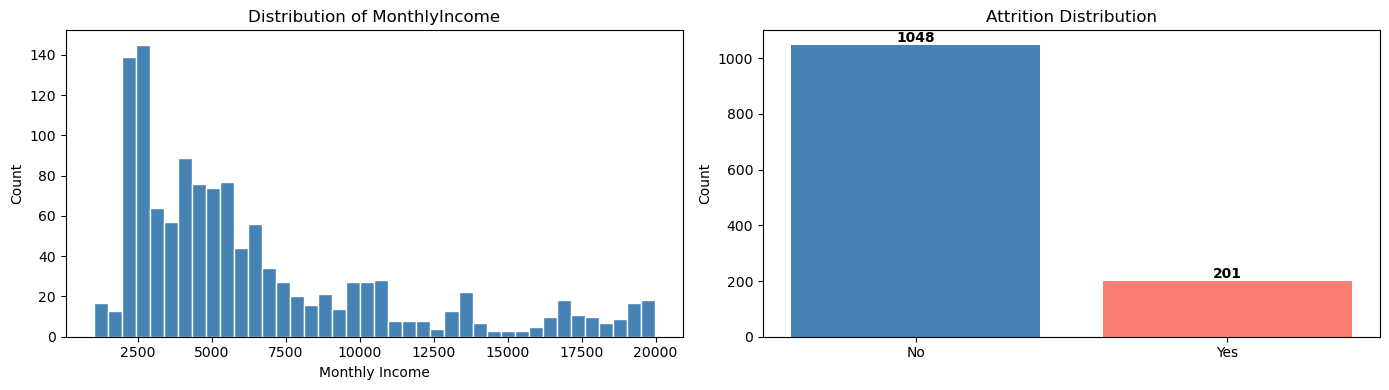

Attrition rate: 16.1%
Class imbalance ratio (No/Yes): 5.2x


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Regression target: MonthlyIncome
axes[0].hist(df['MonthlyIncome'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of MonthlyIncome')
axes[0].set_xlabel('Monthly Income')
axes[0].set_ylabel('Count')

# Classification target: Attrition
counts = df['Attrition'].value_counts()
axes[1].bar(counts.index, counts.values, color=['steelblue', 'salmon'])
axes[1].set_title('Attrition Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Attrition rate: {(df["Attrition"]=="Yes").mean()*100:.1f}%')
print(f'Class imbalance ratio (No/Yes): {counts["No"]/counts["Yes"]:.1f}x')

### 3.4 Correlation with MonthlyIncome

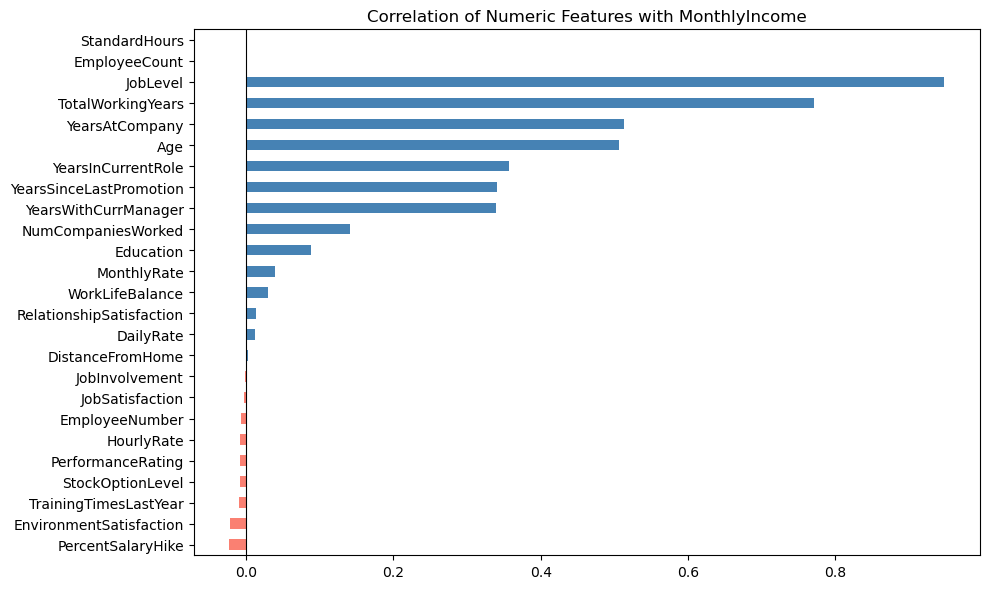

Top 5 positive correlations:
YearsAtCompany       0.513625
TotalWorkingYears    0.771027
JobLevel             0.947914
EmployeeCount             NaN
StandardHours             NaN
Name: MonthlyIncome, dtype: float64


In [11]:
num_cols_all = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols_all].corr()['MonthlyIncome'].drop('MonthlyIncome').sort_values()

plt.figure(figsize=(10, 6))
corr.plot(kind='barh', color=['salmon' if x < 0 else 'steelblue' for x in corr])
plt.title('Correlation of Numeric Features with MonthlyIncome')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Top 5 positive correlations:')
print(corr.tail(5))

### 3.5 Attrition by Key Features

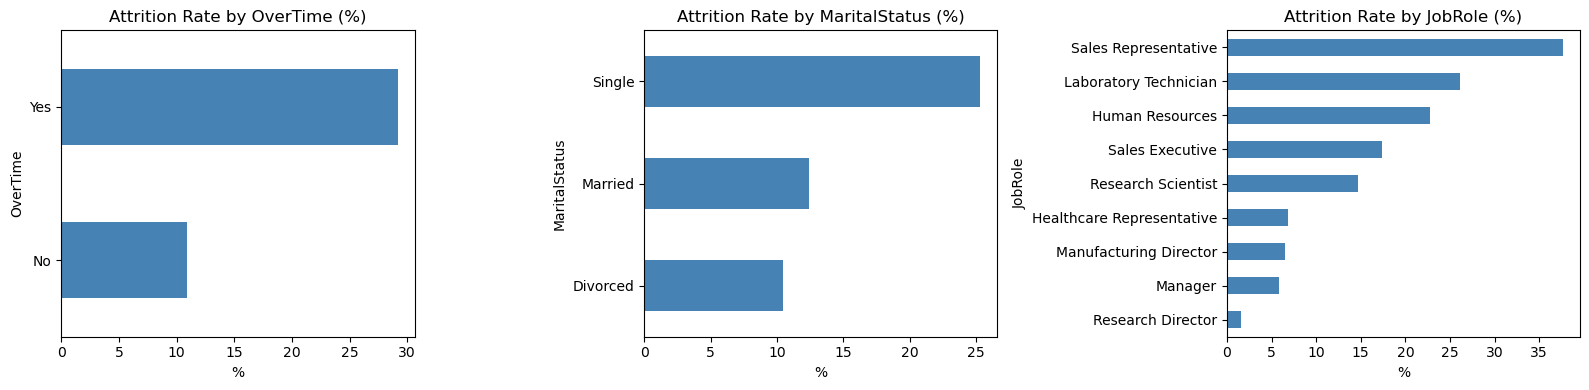

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['OverTime', 'MaritalStatus', 'JobRole']):
    attrition_rate = df.groupby(col)['Attrition'].apply(lambda x: (x=='Yes').mean() * 100)
    attrition_rate.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Attrition Rate by {col} (%)')
    ax.set_xlabel('%')

plt.tight_layout()
plt.show()

### 3.6 Heatmap of Numeric Correlations

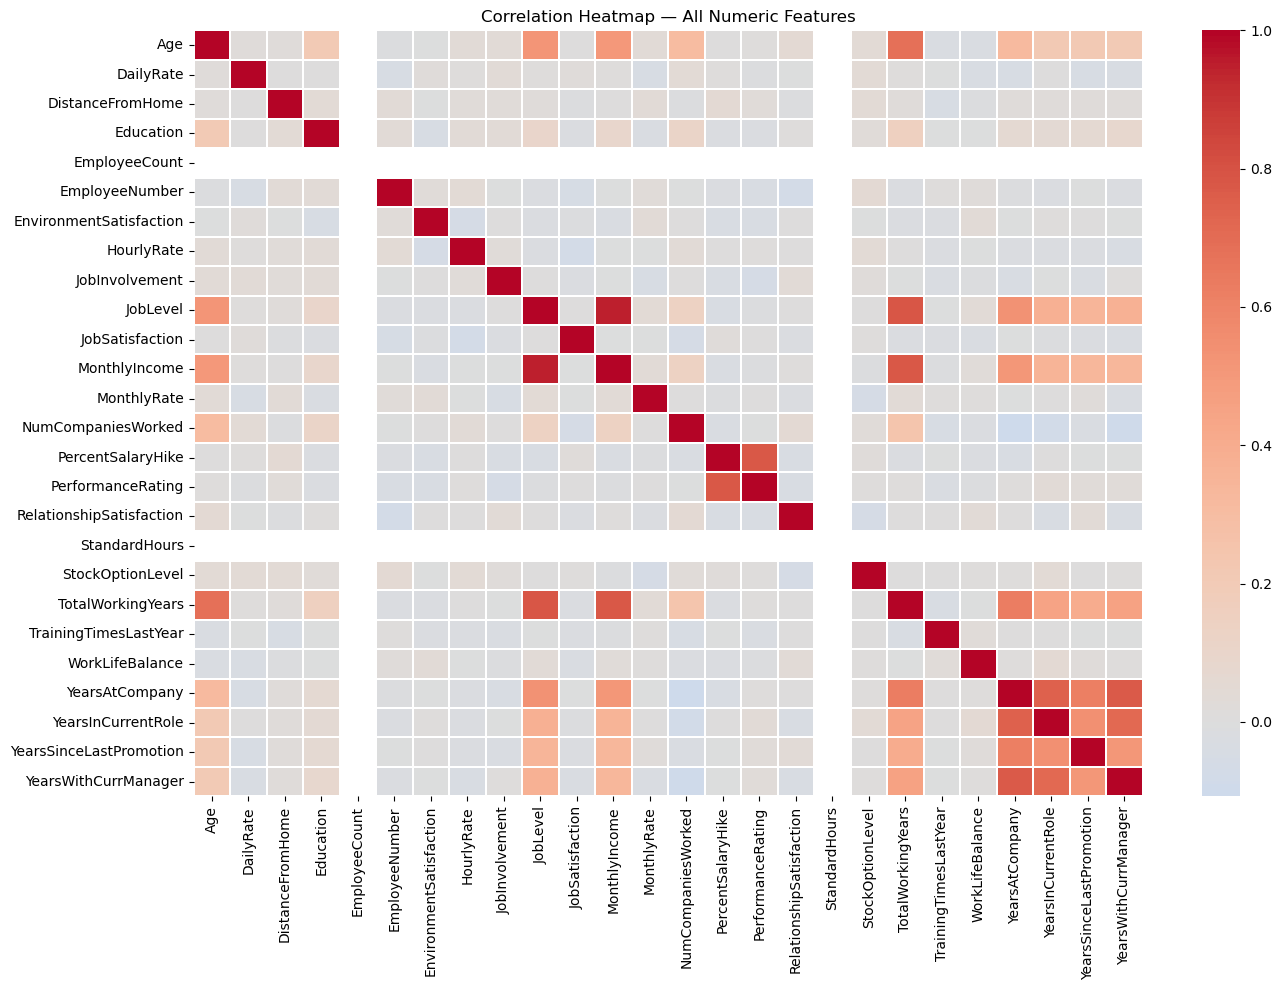

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df[num_cols_all].corr(),
    annot=False, cmap='coolwarm', center=0,
    linewidths=0.3
)
plt.title('Correlation Heatmap — All Numeric Features')
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Preprocessing

In [14]:
target_reg = 'MonthlyIncome'
target_class = 'Attrition'

# --- Regression ---
df_reg = df.drop(columns=DROP_COLS + [target_class])
X_reg = df_reg.drop(columns=[target_reg])
y_reg = df_reg[target_reg]

# --- Classification ---
df_class = df.drop(columns=DROP_COLS + [target_reg])
X_class = df_class.drop(columns=[target_class])
y_class = df_class[target_class]  # 'Yes' / 'No'

cat_cols_reg = X_reg.select_dtypes(include='object').columns.tolist()
num_cols_reg = X_reg.select_dtypes(exclude='object').columns.tolist()

cat_cols_class = X_class.select_dtypes(include='object').columns.tolist()
num_cols_class = X_class.select_dtypes(exclude='object').columns.tolist()

print(f'Regression  — numeric: {len(num_cols_reg)}, categorical: {len(cat_cols_reg)}')
print(f'Classification — numeric: {len(num_cols_class)}, categorical: {len(cat_cols_class)}')
print(f'\nCategorical cols: {cat_cols_reg}')

Regression  — numeric: 22, categorical: 7
Classification — numeric: 22, categorical: 7

Categorical cols: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [15]:
def make_preprocessor(num_cols, cat_cols):
    """
    Builds a ColumnTransformer that:
    - Imputes numeric columns with the median (robust to outliers)
    - Scales numerics with StandardScaler
    - Imputes categoricals with the most frequent value
    - One-hot encodes categoricals (handle_unknown='ignore' for robustness)
    """
    return ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ])

print('Preprocessor factory defined.')

Preprocessor factory defined.


## 5. Algorithm Comparison — Regression

In [16]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
preprocessor_reg = make_preprocessor(num_cols_reg, cat_cols_reg)

reg_models = {
    'Ridge':           Ridge(alpha=1.0),
    'RandomForest':    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':         XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                                    random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM':        LGBMRegressor(n_estimators=500, learning_rate=0.05,
                                     random_state=42, n_jobs=-1, verbose=-1),
}

reg_results = {}
for name, model in reg_models.items():
    pipe = Pipeline([('pre', preprocessor_reg), ('model', model)])
    scores = cross_val_score(pipe, X_reg, y_reg, cv=cv_reg, scoring='r2')
    reg_results[name] = scores
    print(f'{name:20s}  CV R2: {scores.mean():.4f} ± {scores.std():.4f}')

Ridge                 CV R2: 0.9366 ± 0.0089
RandomForest          CV R2: 0.9467 ± 0.0077
XGBoost               CV R2: 0.9407 ± 0.0064
LightGBM              CV R2: 0.9381 ± 0.0096


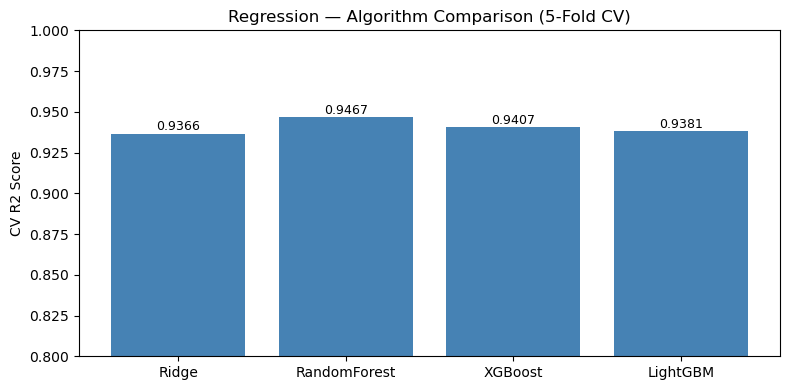

In [17]:
plt.figure(figsize=(8, 4))
means = {k: v.mean() for k, v in reg_results.items()}
plt.bar(means.keys(), means.values(), color='steelblue')
plt.ylim(0.8, 1.0)
plt.ylabel('CV R2 Score')
plt.title('Regression — Algorithm Comparison (5-Fold CV)')
for i, (k, v) in enumerate(means.items()):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Algorithm Comparison — Classification

In [18]:
cv_class = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
preprocessor_class = make_preprocessor(num_cols_class, cat_cols_class)

class_models = {
    'LogisticReg':     LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'RandomForest':    RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                              random_state=42, n_jobs=-1),
    'GradientBoosting':GradientBoostingClassifier(n_estimators=200, random_state=42),
    'LightGBM':        LGBMClassifier(n_estimators=500, learning_rate=0.05, class_weight='balanced',
                                      random_state=42, n_jobs=-1, verbose=-1),
}

class_results = {}
for name, model in class_models.items():
    pipe = Pipeline([('pre', preprocessor_class), ('model', model)])
    scores = cross_val_score(pipe, X_class, y_class, cv=cv_class, scoring='f1_macro')
    class_results[name] = scores
    print(f'{name:20s}  CV F1-macro: {scores.mean():.4f} ± {scores.std():.4f}')

LogisticReg           CV F1-macro: 0.6756 ± 0.0215
RandomForest          CV F1-macro: 0.5712 ± 0.0285
GradientBoosting      CV F1-macro: 0.7093 ± 0.0391
LightGBM              CV F1-macro: 0.6796 ± 0.0225


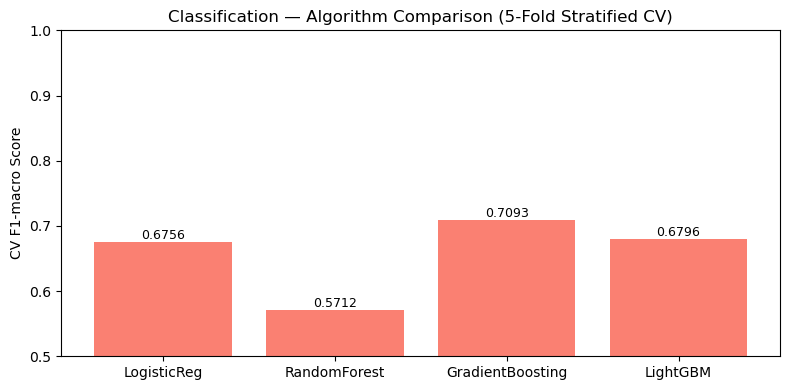

In [19]:
plt.figure(figsize=(8, 4))
means_c = {k: v.mean() for k, v in class_results.items()}
plt.bar(means_c.keys(), means_c.values(), color='salmon')
plt.ylim(0.5, 1.0)
plt.ylabel('CV F1-macro Score')
plt.title('Classification — Algorithm Comparison (5-Fold Stratified CV)')
for i, (k, v) in enumerate(means_c.items()):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning

### 7.1 Regression — XGBoost Tuning (RandomizedSearchCV)

In [20]:
param_dist_reg = {
    'model__n_estimators':    [500, 1000, 2000],
    'model__learning_rate':   [0.01, 0.02, 0.05, 0.1],
    'model__max_depth':       [4, 6, 8],
    'model__subsample':       [0.7, 0.8, 0.9],
    'model__colsample_bytree':[0.7, 0.8, 0.9],
    'model__reg_alpha':       [0.0, 0.1, 0.5],
    'model__reg_lambda':      [0.1, 0.5, 1.0],
}

pipe_reg_tune = Pipeline([
    ('pre', make_preprocessor(num_cols_reg, cat_cols_reg)),
    ('model', XGBRegressor(random_state=42, n_jobs=-1, verbosity=0))
])

rscv_reg = RandomizedSearchCV(
    pipe_reg_tune, param_dist_reg,
    n_iter=20, cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2', random_state=42, n_jobs=-1, verbose=1
)
rscv_reg.fit(X_reg, y_reg)
print(f'Best CV R2: {rscv_reg.best_score_:.4f}')
print(f'Best params: {rscv_reg.best_params_}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV R2: 0.9460
Best params: {'model__subsample': 0.9, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.5, 'model__n_estimators': 500, 'model__max_depth': 4, 'model__learning_rate': 0.02, 'model__colsample_bytree': 0.8}


### 7.2 Classification — LightGBM Tuning (RandomizedSearchCV)

In [21]:
param_dist_class = {
    'model__n_estimators':    [500, 1000, 2000],
    'model__learning_rate':   [0.01, 0.02, 0.05, 0.1],
    'model__max_depth':       [4, 5, 6, 8],
    'model__num_leaves':      [31, 63, 127],
    'model__subsample':       [0.7, 0.8, 0.9],
    'model__colsample_bytree':[0.7, 0.8, 0.9],
}

pipe_class_tune = Pipeline([
    ('pre', make_preprocessor(num_cols_class, cat_cols_class)),
    ('model', LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1))
])

rscv_class = RandomizedSearchCV(
    pipe_class_tune, param_dist_class,
    n_iter=20, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1
)
rscv_class.fit(X_class, y_class)
print(f'Best CV F1-macro: {rscv_class.best_score_:.4f}')
print(f'Best params: {rscv_class.best_params_}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV F1-macro: 0.7164
Best params: {'model__subsample': 0.8, 'model__num_leaves': 63, 'model__n_estimators': 2000, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}


## 8. Final Pipelines (Full Training)

In [22]:
# --- Final Regression Pipeline ---
pipeline_regression = Pipeline([
    ('preprocessor', make_preprocessor(num_cols_reg, cat_cols_reg)),
    ('model', XGBRegressor(
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=8,
        min_child_weight=1,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.0,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])

pipeline_regression.fit(X_reg, y_reg)
train_r2 = r2_score(y_reg, pipeline_regression.predict(X_reg))
print(f'Regression — Train R2: {train_r2:.4f}')

Regression — Train R2: 1.0000


In [23]:
# --- Final Classification Pipeline ---
pipeline_classification = Pipeline([
    ('preprocessor', make_preprocessor(num_cols_class, cat_cols_class)),
    ('model', LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=8,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

pipeline_classification.fit(X_class, y_class)
train_preds = pipeline_classification.predict(X_class)
train_f1 = f1_score(y_class, train_preds, average='macro')
print(f'Classification — Train F1-macro: {train_f1:.4f}')

Classification — Train F1-macro: 1.0000


## 9. Model Evaluation & Analysis

### 9.1 Regression — Predicted vs Actual

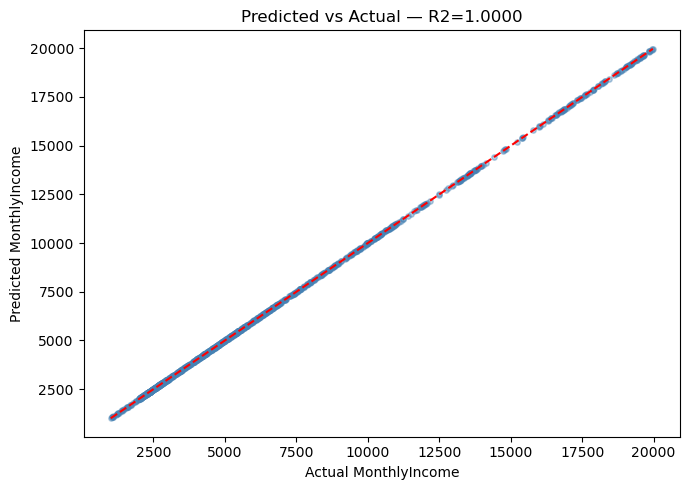

In [24]:
y_pred_reg = pipeline_regression.predict(X_reg)

plt.figure(figsize=(7, 5))
plt.scatter(y_reg, y_pred_reg, alpha=0.4, s=15, color='steelblue')
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--', lw=1.5)
plt.xlabel('Actual MonthlyIncome')
plt.ylabel('Predicted MonthlyIncome')
plt.title(f'Predicted vs Actual — R2={r2_score(y_reg, y_pred_reg):.4f}')
plt.tight_layout()
plt.show()

### 9.2 Regression — Feature Importance

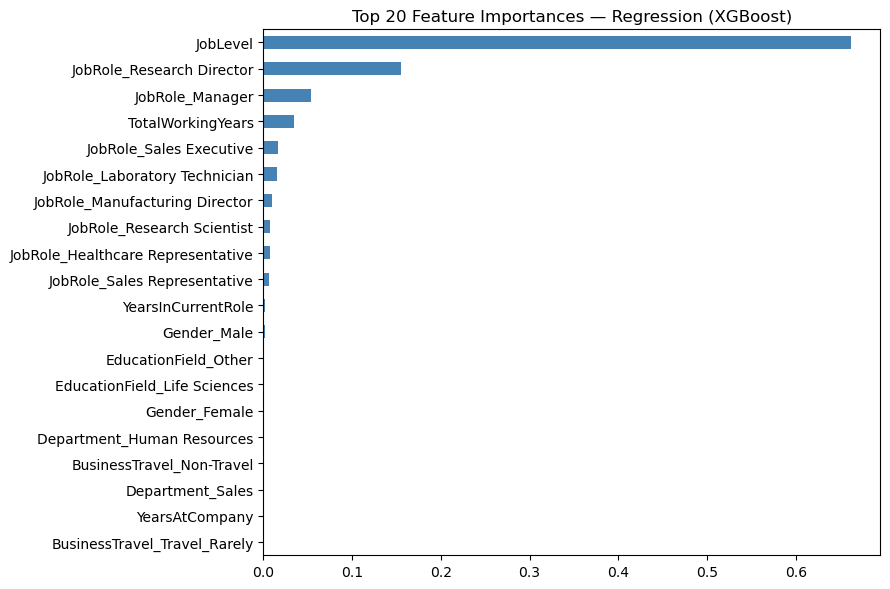

In [25]:
xgb_model = pipeline_regression.named_steps['model']
pre = pipeline_regression.named_steps['preprocessor']

ohe_features = pre.named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols_reg).tolist()
feature_names = num_cols_reg + ohe_features

importances = pd.Series(xgb_model.feature_importances_, index=feature_names)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 6))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importances — Regression (XGBoost)')
plt.tight_layout()
plt.show()

### 9.3 Classification — Confusion Matrix

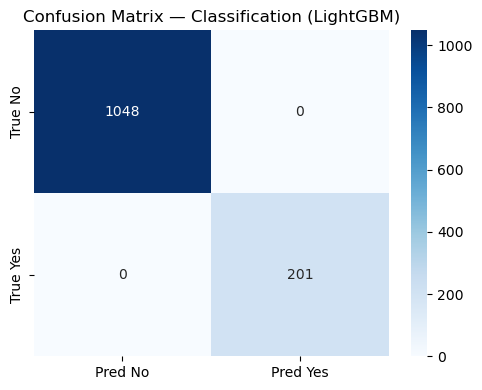

              precision    recall  f1-score   support

          No       1.00      1.00      1.00      1048
         Yes       1.00      1.00      1.00       201

    accuracy                           1.00      1249
   macro avg       1.00      1.00      1.00      1249
weighted avg       1.00      1.00      1.00      1249



In [26]:
cm = confusion_matrix(y_class, train_preds, labels=['No', 'Yes'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No', 'Pred Yes'],
            yticklabels=['True No', 'True Yes'])
plt.title('Confusion Matrix — Classification (LightGBM)')
plt.tight_layout()
plt.show()

print(classification_report(y_class, train_preds))

### 9.4 Classification — Feature Importance

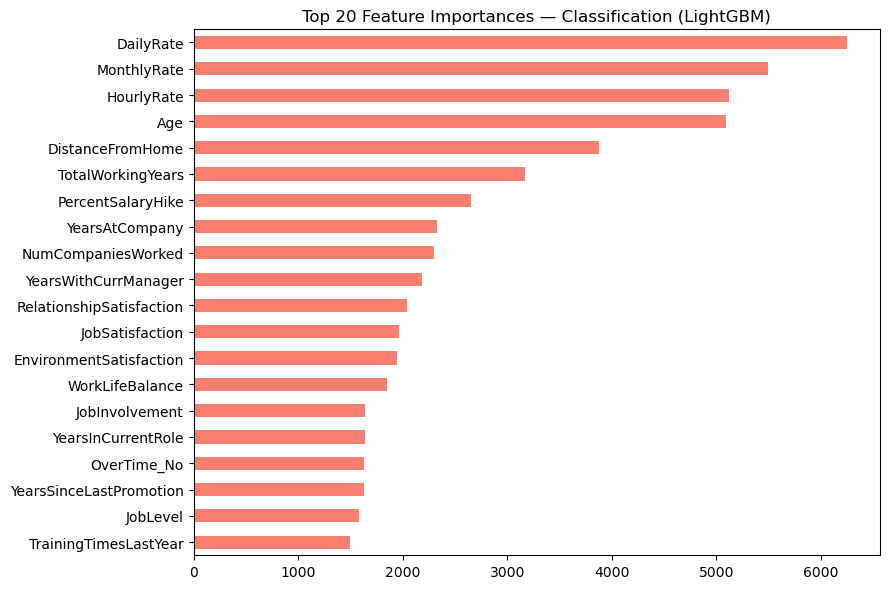

In [27]:
lgbm_model = pipeline_classification.named_steps['model']
pre_c = pipeline_classification.named_steps['preprocessor']

ohe_features_c = pre_c.named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols_class).tolist()
feature_names_c = num_cols_class + ohe_features_c

importances_c = pd.Series(lgbm_model.feature_importances_, index=feature_names_c)
top20_c = importances_c.sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 6))
top20_c.sort_values().plot(kind='barh', color='salmon')
plt.title('Top 20 Feature Importances — Classification (LightGBM)')
plt.tight_layout()
plt.show()

## 10. Export Pipelines

In [28]:
with open('G1_pipeline_regression.pkl', 'wb') as f:
    pickle.dump(pipeline_regression, f)
print('Saved G1_pipeline_regression.pkl')

with open('G1_pipeline_classification.pkl', 'wb') as f:
    pickle.dump(pipeline_classification, f)
print('Saved G1_pipeline_classification.pkl')

Saved G1_pipeline_regression.pkl
Saved G1_pipeline_classification.pkl


## 11. Validation with Evaluator Logic

In [30]:
# Replicates exactly what avaliador.py does
import pickle
from sklearn.metrics import r2_score, f1_score

dados_teste = pd.read_csv('../employee_data/employee_data.csv')

X_eval_class = dados_teste.drop(['Attrition'], axis=1)
y_real_class = dados_teste['Attrition']

X_eval_reg = dados_teste.drop(['MonthlyIncome'], axis=1)
y_real_reg = dados_teste['MonthlyIncome']

with open('G1_pipeline_regression.pkl', 'rb') as f:
    p_reg = pickle.load(f)
with open('G1_pipeline_classification.pkl', 'rb') as f:
    p_class = pickle.load(f)

pred_reg   = p_reg.predict(X_eval_reg)
score_reg  = r2_score(y_real_reg, pred_reg)

pred_class  = p_class.predict(X_eval_class)
score_class = f1_score(y_real_class, pred_class, average='macro')

score_final = (score_reg + score_class) / 2

print(f'-> Regressão  (R2): {score_reg:.4f}')
print(f'-> Classificação (F1): {score_class:.4f}')
print(f'-> Score Combinado Final: {score_final:.4f}')

-> Regressão  (R2): 1.0000
-> Classificação (F1): 1.0000
-> Score Combinado Final: 1.0000


## 12. GenAI Queries Used

The following prompts were used during interaction with Generative AI tools as part of the project:

1. *"What are the best strategies to handle class imbalance in a binary classification problem with a 5:1 ratio (No:Yes)?"* — Led to the use of `class_weight='balanced'` in LightGBM.

2. *"How should I structure a Scikit-Learn Pipeline that handles both numerical imputation/scaling and categorical encoding in a single step?"* — Confirmed the `ColumnTransformer` + nested `Pipeline` approach.

3. *"What hyperparameters are most impactful to tune in XGBoost for regression tasks?"* — Guided the `RandomizedSearchCV` parameter space (n_estimators, learning_rate, max_depth, subsample, colsample_bytree, reg_alpha, reg_lambda).

4. *"Why should OneHotEncoder use handle_unknown='ignore' in a production pipeline?"* — Ensures the pipeline doesn't crash on unseen category values during blind test evaluation.

5. *"Can LightGBM classify directly with string labels ('Yes'/'No') without needing a LabelEncoder?"* — Confirmed LightGBM natively supports string target labels, unlike XGBoost.
